In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [2]:
def european_digital_option_price(S0, K, T, r, sigma, q=0, option_type='call'):

    d2 = (np.log(S0 / K) + (r - q - 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    
    if option_type == 'call':
        return np.exp(-r * T) * norm.cdf(d2)
    elif option_type == 'put':
        return np.exp(-r * T) * norm.cdf(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")


In [3]:
def european_digital_option_delta_numeric(S0, K, T, r, sigma, q=0, option_type='call', h=0.001):
    
    price_up = european_digital_option_price(S0+h, K, T, r, sigma, q, option_type)
    price_down = european_digital_option_price(S0-h, K, T, r, sigma, q, option_type)
    
    derivative = (price_up - price_down) / (2 * h)
    return derivative

In [4]:
def european_digital_option_vega_numeric(S0, K, T, r, sigma, q=0, option_type='call', h=0.001):
    
    price_up = european_digital_option_price(S0, K, T, r, sigma+h, q, option_type)
    price_down = european_digital_option_price(S0, K, T, r, sigma-h, q, option_type)
    
    derivative = (price_up - price_down) / (2 * h)
    return derivative

In [5]:
# Parameters
K = 100       # Strike
r = 0.05       # Risk-free interest rate
sigma = 0.2    # Volatility

# Underlying price range
S0 = np.linspace(60, 140, 300)

# Time to maturities in years
T_values = [0.001, 1/12, 0.5, 1, 5]  # 1 month, 6 months, 1 year

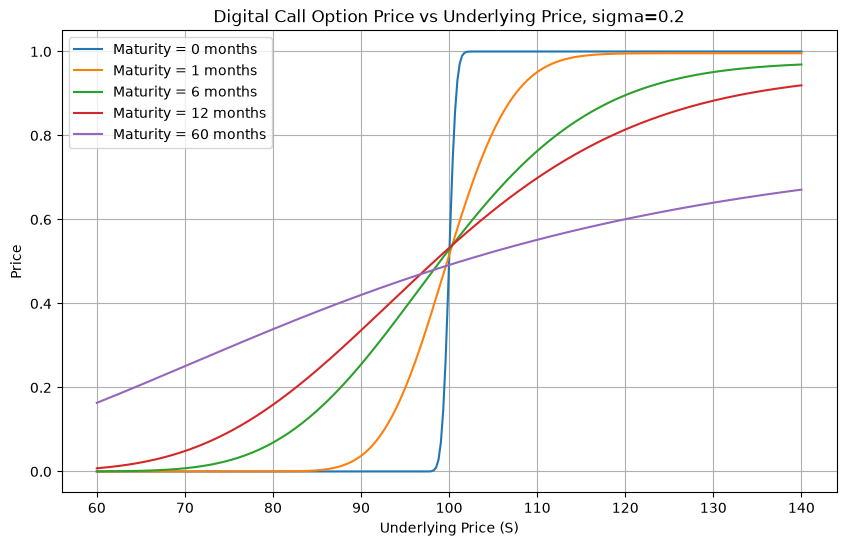

In [6]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_digital_option_price(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"Digital Call Option Price vs Underlying Price, sigma={sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

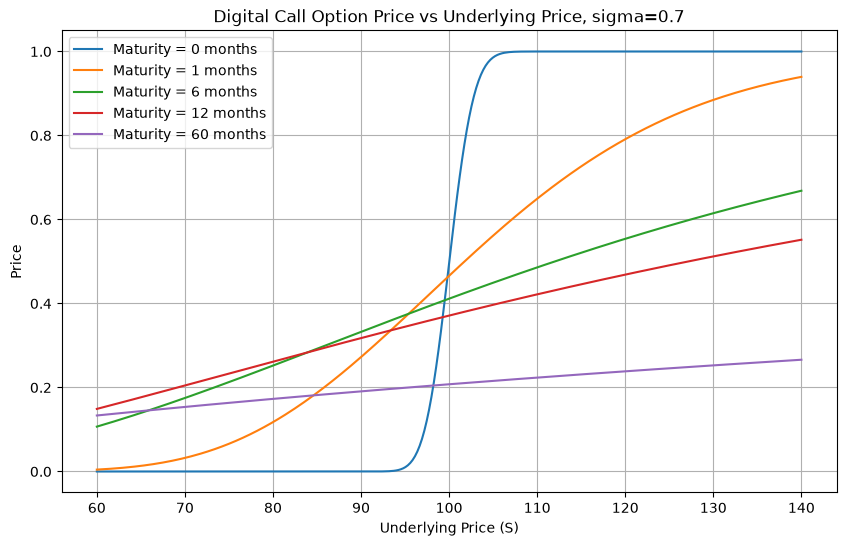

In [7]:
# Plotting
high_sigma = 0.7
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_digital_option_price(S0, K, T, r, high_sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title(f"Digital Call Option Price vs Underlying Price, sigma={high_sigma}")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

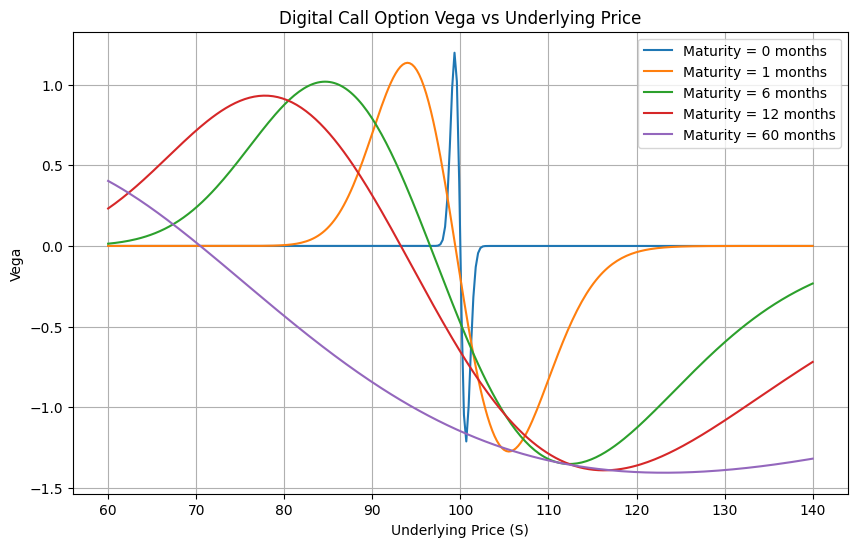

In [24]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_digital_option_vega_numeric(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title("Digital Call Option Vega vs Underlying Price")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Vega")
plt.legend()
plt.grid(True)
plt.show()

# OOM: vol is good
## How good - depends on TTM and How far OOM. If I am super close to K, then little change in vol doesn't matter that much. But when I am mid distance from K vol is important.

# ITM : vol is bad - because VOL INCREASES RANGE OF POSSIBILITIES but my upside is 1 at most

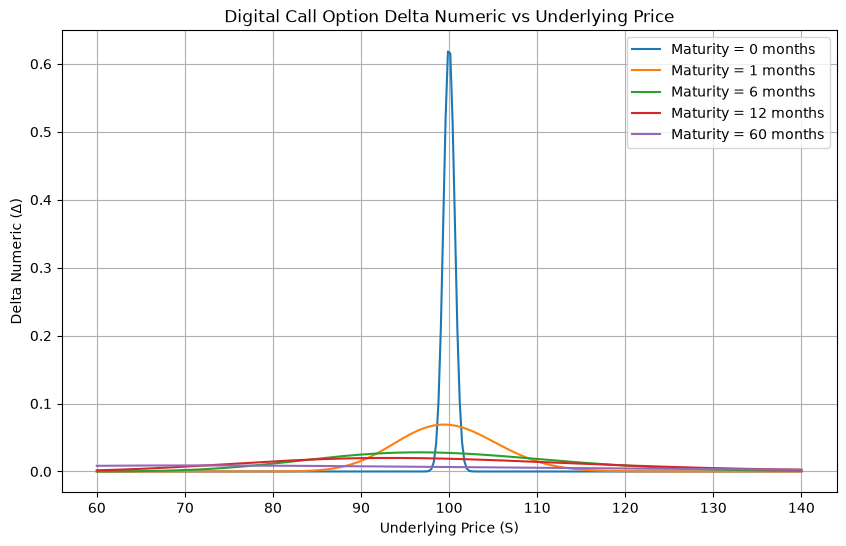

In [8]:
# Plotting
plt.figure(figsize=(10, 6))
for T in T_values:
    delta = european_digital_option_delta_numeric(S0, K, T, r, sigma)
    plt.plot(S0, delta, label=f'Maturity = {T*12:.0f} months')

# Customizing plot
plt.title("Digital Call Option Delta Numeric vs Underlying Price")
plt.xlabel("Underlying Price (S)")
plt.ylabel("Delta Numeric (Δ)")
plt.legend()
plt.grid(True)
plt.show()